# Univariate Exploratory Data Analysis

In this notebook I will perform univariate analysis, an analysis applied to each variable individually.

## Objectives
1. Analyze each feature's distribution 
2. Identify patterns 
3. Discover patterns that can inform feature engineering
4. Validate hypotheses based on my intuition and experience without having observed the data

## Setup

In [1]:
import sys
import os
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(".."))
from src import get_stats

data = pd.read_parquet("../data/bronze/clean_dataset.parquet",  engine='pyarrow')
data = data.sort_values(["date", "time"]).reset_index(drop=True)

In [2]:
data.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0


In [3]:
data.tail()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
149995,2024-12-30,22:58:00,CNR9030698,CID6939658,Bike,DLF Phase 3,Okhla,6.9,35.799999,440.0,12.850000,UPI,0.0
149996,2024-12-30,23:03:14,CNR1507833,CID9905090,eBike,Saket,Noida Sector 62,7.9,33.599998,279.0,39.360001,UPI,0.0
149997,2024-12-30,23:17:05,CNR2265113,CID4170406,Go Mini,GTB Nagar,Anand Vihar ISBT,9.9,39.900002,1855.0,38.910000,UPI,0.0
149998,2024-12-30,23:21:12,CNR4066733,CID8938559,Uber XL,Ashram,Vasant Kunj,2.6,26.700001,520.0,36.369999,Uber Wallet,0.0
149999,2024-12-30,23:36:11,CNR6915581,CID5185745,Auto,Pitampura,Nehru Place,3.5,11.900000,571.0,2.670000,UPI,0.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   date             150000 non-null  object  
 1   time             150000 non-null  object  
 2   booking_id       150000 non-null  string  
 3   customer_id      150000 non-null  string  
 4   vehicle_type     150000 non-null  category
 5   pickup_location  150000 non-null  category
 6   drop_location    150000 non-null  category
 7   avg_vtat         139500 non-null  float32 
 8   avg_ctat         102000 non-null  float32 
 9   booking_value    102000 non-null  float32 
 10  ride_distance    102000 non-null  float32 
 11  payment_method   102000 non-null  category
 12  is_cancelled     150000 non-null  float32 
dtypes: category(4), float32(5), object(2), string(2)
memory usage: 8.3+ MB


In [5]:
get_stats(data)

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
count,150000,150000,150000,150000,150000,150000,150000,139500.0,102000.0,102000.0,102000.0,102000,150000.0
unique,365,62910,148767,148788,7,176,176,NaN,NaN,NaN,NaN,5,NaN
top,2024-11-16,17:44:57,CNR2726142,CID5481002,Auto,Khandsa,Ashram,NaN,NaN,NaN,NaN,UPI,NaN
freq,462,16,3,3,37419,949,936,NaN,NaN,NaN,NaN,45909,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456351,29.149632,508.295929,24.637012,NaN,0.32
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,395.805756,14.002138,NaN,0.466478
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,10.0,50.0,1.0,NaN,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.3,21.6,234.0,12.46,NaN,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.3,28.799999,414.0,23.719999,NaN,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.3,36.799999,689.0,36.82,NaN,1.0


150000 samples with 12 columns. We have date and time so the data is ordered and a is_cancelled label already binarized.

Columns with:
- Null values: avg_vtat, avg_ctat, booking_value, ride_distance, payment_method


## Univariate Analysis


Are there potential duplicate bookings where the same customer, time, and location appear more than once?


In [6]:
potential_dup_cols = ['customer_id', 'date', 'time', 'pickup_location', 'drop_location']

if all(col in data.columns for col in potential_dup_cols):
    potential_dups = data.duplicated(subset=potential_dup_cols).sum()
    print(f"\nPotential duplicate bookings: {potential_dups:,}")



Potential duplicate bookings: 0


### date


How are the top 20 most frequent dates distributed, and do any anomalies or patterns stand out?


In [7]:
date_counts = data['date'].value_counts()
date_counts.head(20)

date
2024-11-16    462
2024-09-18    456
2024-05-09    456
2024-02-06    452
2024-10-12    452
2024-01-26    452
2024-10-13    451
2024-10-09    451
2024-07-17    451
2024-11-29    450
2024-04-01    449
2024-02-16    449
2024-01-21    449
2024-03-12    448
2024-07-05    446
2024-03-18    446
2024-04-26    446
2024-02-04    446
2024-12-22    446
2024-05-14    445
Name: count, dtype: int64

There is no clear pattern here. Almost every month has a day with a really high amount of bookings

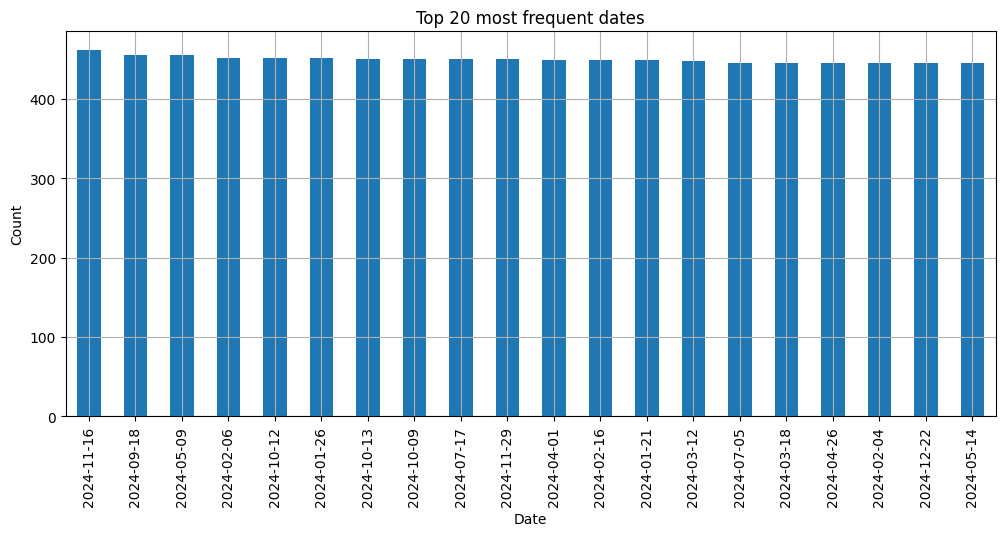

In [8]:
plt.figure(figsize=(12,5))
date_counts.head(20).plot(kind='bar')
plt.title("Top 20 most frequent dates")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid()
plt.show()


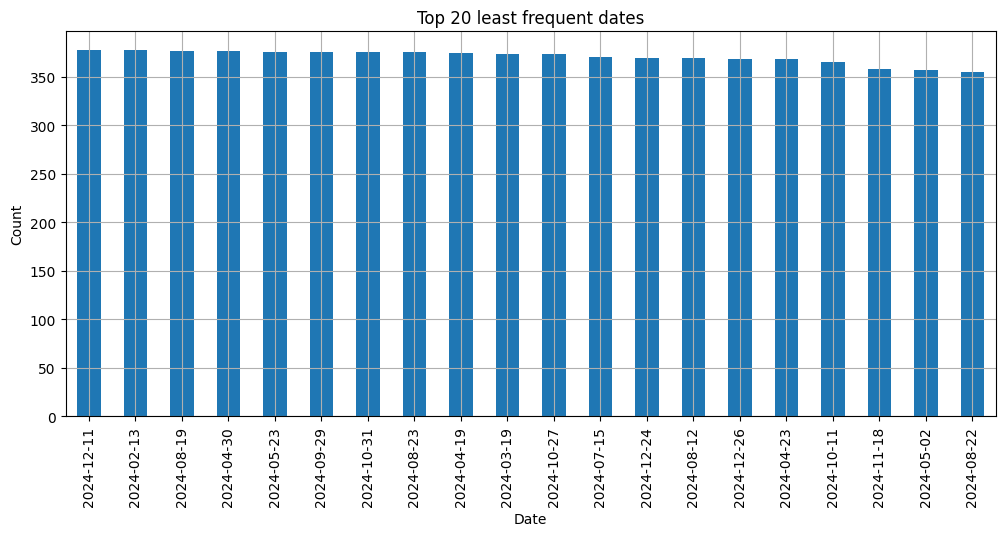

In [9]:
plt.figure(figsize=(12,5))
date_counts.tail(20).plot(kind='bar')
plt.title("Top 20 least frequent dates")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid()
plt.show()


The spread across the top 20 days is only 17 bookings, which is quite narrow. Why does it cap at that level? Is it a coincidence, some kind of capacity bottleneck, or simply the natural demand ceiling for this city?

Each day of the year has roughly between 350 and 460 records.

It would be worth checking whether these high-traffic days correspond to holidays or special events, and whether the relationship with cancellations suggests this is genuine peak demand or a flattening effect caused by service limitations.

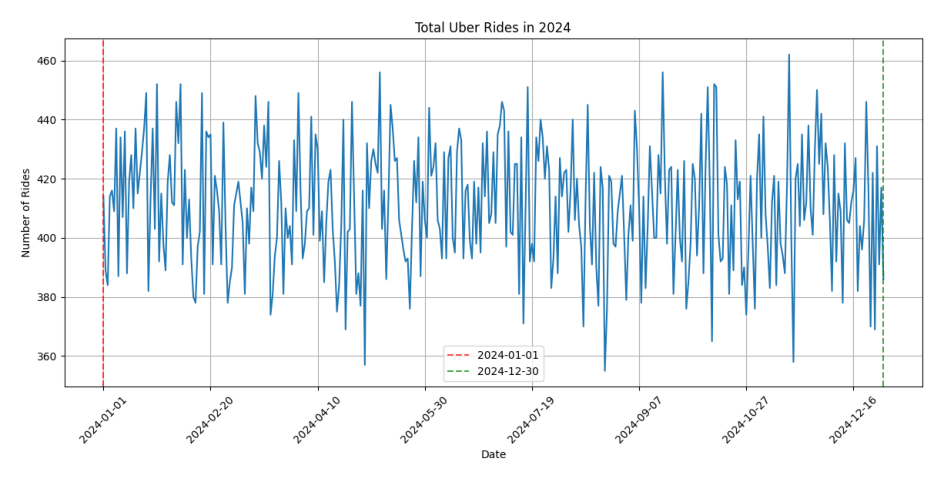

In [10]:

# Given the computational constrains of my laptop and the size of some plots, I store them in images/  

plot_file = 'imgs/date_lineplot.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')  
    plt.show()
else:
    plt.figure(figsize=(12, 6))
    daily_counts = data.groupby('date').size()
    plt.plot(daily_counts.index, daily_counts.values)

    first_date = daily_counts.index.min()
    last_date = daily_counts.index.max()
    first_date_label = daily_counts.index.min()
    last_date_label = daily_counts.index.max()
    plt.axvline(first_date, color='red', linestyle='--', alpha=0.7, label=first_date_label)
    plt.axvline(last_date, color='green', linestyle='--', alpha=0.7, label=last_date_label)
    plt.title('Total Uber Rides in 2024')
    plt.xlabel('Date')
    plt.ylabel('Number of Rides')

    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.grid()
    plt.legend()
    plt.tight_layout()
    os.makedirs('imgs', exist_ok=True) 
    plt.savefig(plot_file)
    plt.show()



How can there be 365 unique date values if December 31st is missing? Could this be a leap year with a February 29th entry?

In [11]:
data[data["date"] == "2024-02-29"].head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
24403,2024-02-29,00:00:09,CNR2330207,CID8309113,Auto,Kirti Nagar,Sonipat,9.3,NaN,NaN,NaN,NaN,1.0
24404,2024-02-29,00:08:57,CNR6004216,CID5184316,Go Mini,Meerut,Ghitorni Village,2.8,21.799999,621.0,6.470000,Credit Card,0.0
24405,2024-02-29,00:24:06,CNR1464111,CID1168333,Premier Sedan,Malviya Nagar,Udyog Vihar,3.2,20.200001,444.0,28.160000,Cash,0.0
24406,2024-02-29,00:36:19,CNR3852671,CID4695190,Premier Sedan,Malviya Nagar,Connaught Place,NaN,NaN,NaN,NaN,NaN,1.0
24407,2024-02-29,01:10:18,CNR9446862,CID3841042,Bike,Okhla,Sarojini Nagar,3.7,25.400000,362.0,37.630001,Credit Card,0.0


Confirmed, it's a leap year, that accounts for the 365 unique dates. We need talk with the team and try to find data from the 31st of Dec



### time

How are the top 20 most frequent times distributed, and do any anomalies or patterns stand out?

In [12]:
time = data['time'].value_counts()
time.head(20)

time
17:44:57    16
19:17:33    12
17:54:33    11
18:59:55    11
17:55:08    11
11:29:50    11
19:26:48    11
10:23:23    11
15:23:56    11
19:29:07    10
17:38:15    10
18:07:46    10
18:09:57    10
17:34:15    10
18:17:18    10
20:46:08    10
16:16:59    10
19:44:48    10
18:10:37    10
09:45:20    10
Name: count, dtype: int64

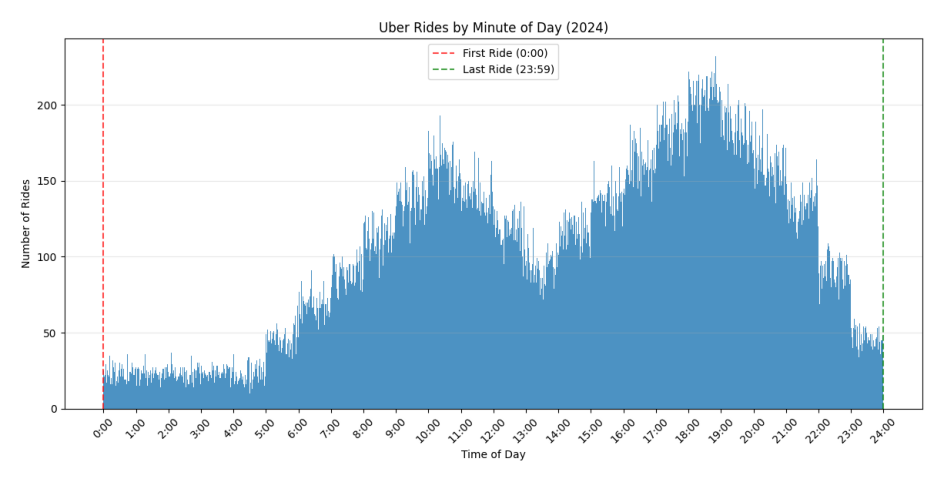

In [13]:
plot_file = 'imgs/time_hist_minute.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    time_parsed = pd.to_datetime(data['time'], format='%H:%M:%S')
    minutes = time_parsed.dt.hour * 60 + time_parsed.dt.minute

    first_min = int(minutes.min())
    last_min = int(minutes.max())

    plt.figure(figsize=(12, 6))
    plt.hist(minutes, bins=range(0, 1441, 1), edgecolor='none', alpha=0.8)

    plt.axvline(first_min, color='red', linestyle='--', alpha=0.7, label=f'First Ride ({first_min // 60}:{first_min % 60:02d})')
    plt.axvline(last_min, color='green', linestyle='--', alpha=0.7, label=f'Last Ride ({last_min // 60}:{last_min % 60:02d})')

    hour_ticks = list(range(0, 1441, 60))
    hour_labels = [f'{h}:00' for h in range(25)]
    plt.xticks(hour_ticks, hour_labels, rotation=45)

    plt.title('Uber Rides by Minute of Day (2024)')
    plt.xlabel('Time of Day')
    plt.ylabel('Number of Rides')
    plt.grid(True, alpha=0.3, axis='y')
    plt.legend()
    plt.tight_layout()

    os.makedirs('imgs', exist_ok=True)
    plt.savefig(plot_file)
    plt.show()


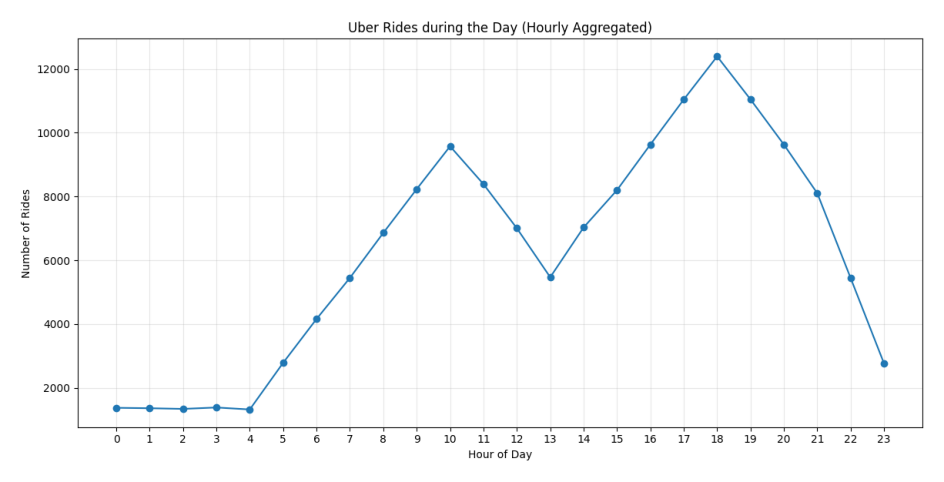

In [14]:
plot_file = 'imgs/time_lineplot_hour.png'

if os.path.exists(plot_file):
    img = plt.imread(plot_file)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    plt.figure(figsize=(12, 6))
    time_parsed = pd.to_datetime(data['time'], format='%H:%M:%S')
    time_counts = (
        data
        .assign(hour=time_parsed.dt.hour)
        .groupby('hour')
        .size()
        .sort_index()
    )

    plt.plot(time_counts.index, time_counts.values)

    first_hour = time_counts.index.min()
    last_hour = time_counts.index.max()
    plt.axvline(first_hour, color='red', linestyle='--', alpha=0.7, label=f'First Hour ({first_hour}:00)')
    plt.axvline(last_hour, color='green', linestyle='--', alpha=0.7, label=f'Last Hour ({last_hour}:00)')

    plt.title('Uber Rides during the Day (Hourly)')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Rides')

    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    os.makedirs('imgs', exist_ok=True)
    plt.savefig(plot_file)
    plt.show()


The plots reveal a clear bimodal daily pattern in ride demand. Activity is minimal during the early morning hours, rises sharply during the morning commute with a peak around 10 AM, dips around midday, and reaches its highest level in the early evening (around 6 PM). Demand then steadily declines toward the end of the day. This pattern could be a useful signal for feature engineering

### new date + time related features

In [15]:
# the 1st of January of 2024 was Monday

data['datetime'] = pd.to_datetime(data['date'] + " " + data['time'], format="%Y-%m-%d %H:%M:%S")

# since there is a clear pattern seen in "time" I create "hour"
data['hour'] = data['datetime'].dt.hour
data['weekday'] = data['datetime'].dt.weekday
data['month'] = data['datetime'].dt.month
data['is_weekend'] = data['weekday'] >= 5

#these are useful to protect the cycle of the day so the begining and then end will be both close to the same value
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)


weekday
0    408.377358
1    411.365385
2    411.788462
3    407.980769
4    411.480769
5    414.269231
6    411.500000
dtype: float64


<Axes: title={'center': 'Average Activity per Weekday (Normalized)'}, xlabel='weekday'>

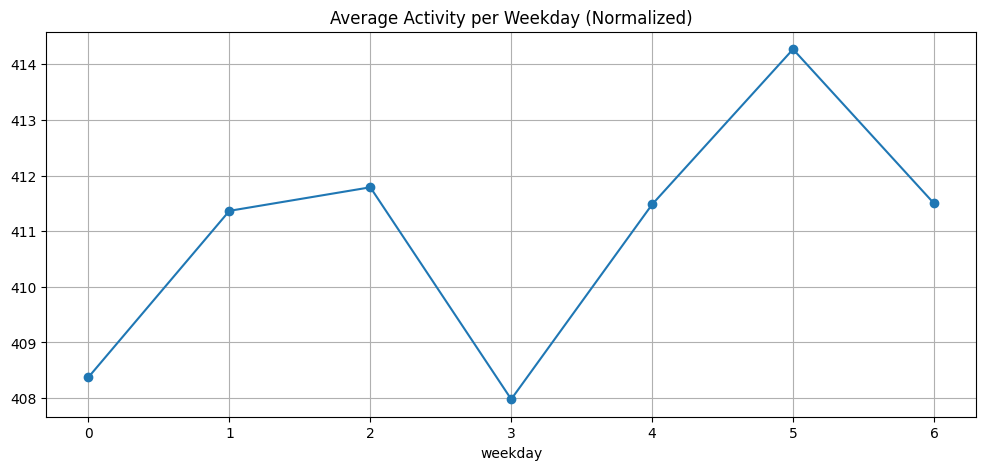

In [16]:
# How is the behaviour of each day?

weekday_counts = data.groupby('weekday').size()

days_per_weekday = data.groupby('weekday')['date'].nunique()
normalized_weekday = weekday_counts / days_per_weekday
print(normalized_weekday)

normalized_weekday.plot(
    kind='line',
    marker='o',
    figsize=(12,5),
    title="Average Activity per Weekday (Normalized)",
    grid=True
)



There is no clear difference between weekdays in this plot; the number of bookings appears to be approximately the same each day 

month
1     414.870968
2     411.275862
3     410.290323
4     406.633333
5     412.193548
6     414.666667
7     416.032258
8     407.612903
9     408.266667
10    408.096774
11    413.133333
12    408.333333
dtype: float64


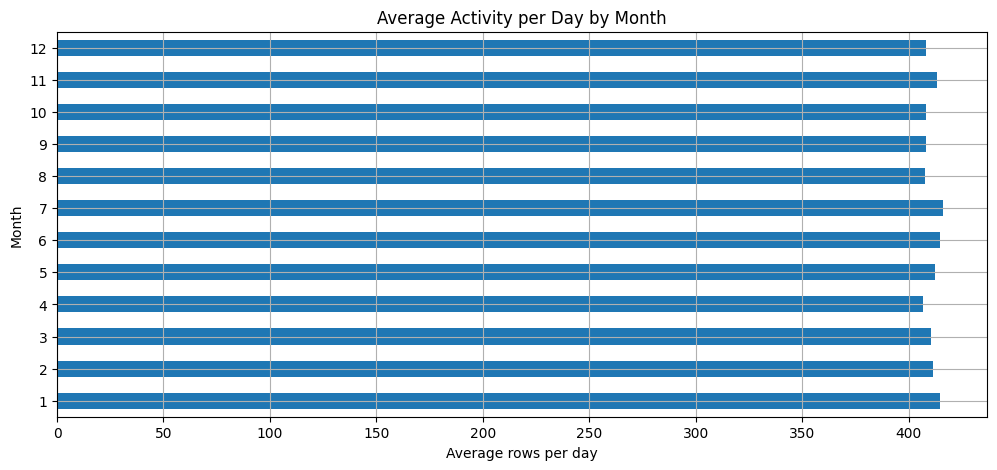

In [17]:
# How is the behaviour of each month?

month_counts = data.groupby('month').size()
days_per_month = data.groupby('month')['date'].nunique()
normalized_month = month_counts / days_per_month

print(normalized_month)

plt.figure(figsize=(12, 5))
normalized_month.plot(
    kind='barh',
    title="Average Activity per Day by Month",
    grid=True
)

plt.xlabel("Average rows per day")
plt.ylabel("Month")
plt.show()




There are no clear patterns in this variable

is_weekend
Weekday    410.191571
Weekend    412.884615
dtype: float64


<Axes: title={'center': 'Average Activity per Day (Weekend vs Weekday)'}, xlabel='is_weekend'>

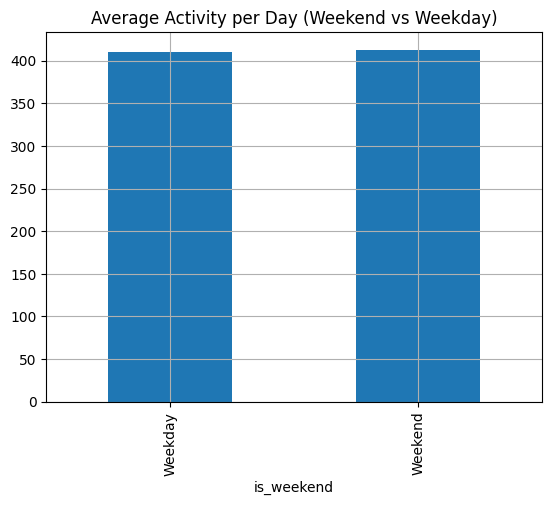

In [18]:
# Is the behaviour changing in the weekend? 

avg_activity = (
    data.groupby('is_weekend')
        .size()
        / data.groupby('is_weekend')['date'].nunique()
)


avg_activity.index = avg_activity.index.map({True: 'Weekend',False: 'Weekday'})

print(avg_activity)

avg_activity.plot(
    kind='bar',
    title='Average Activity per Day (Weekend vs Weekday)',
    grid=True
)


After normalizing by the number of days, weekend and weekday activity levels are comparable, indicating no strong weekend effect

In [19]:
data[["hour_sin", "hour_cos"]].describe()

,hour_sin,hour_cos
count,150000.000000,150000.000000
mean,-0.242204,-0.212834
std,0.714842,0.620520
min,-1.000000,-1.000000
25%,-0.866025,-0.707107
50%,-0.500000,-0.258819
75%,0.500000,0.258819
max,1.000000,1.000000


To capture the cyclical nature of time, the hour of day was encoded using sine and cosine transformations. This representation preserves the circular structure of time, ensuring that adjacent hours such as 23:00 and 00:00 are represented as similar values.

### booking_id


In [20]:
# format check

data['booking_length'] = data['booking_id'].str.len()
print(f"Unique lengths of booking_id strings: {data['booking_length'].nunique()}")
print(f"Total booking_ids: {data['booking_length'].value_counts().sum()}")
print(f"Example booking_id: {data['booking_id'].iloc[0]}")


Unique lengths of booking_id strings: 1
Total booking_ids: 150000
Example booking_id: CNR4352144


what is the letter code in front of the number? how many do we have? 


In [21]:
import re

data[["letters_b", "numbers_b"]] = data["booking_id"].str.extract(r"([A-Za-z]+)([0-9]+)")

count_letters_b = data["letters_b"].value_counts(dropna = False)
count_numbers_b = data["numbers_b"].value_counts(dropna = False)

# are the values in front of the numbers valuable?
count_letters_b
# count_numbers_b

letters_b
CNR    150000
Name: count, dtype: Int64

All rows share the same letter code "CNR", the number is the unique identifier

what is the range of the numbers?
how many duplicated booking IDs there are and how many times? why?

In [22]:
count_numbers = count_numbers_b.astype("int32").sort_index()
print(f" The min value is: {count_numbers_b.idxmin()}, the max value is: {count_numbers_b.idxmax()}")


 The min value is: 1405409, the max value is: 2726142


I will leave for a further analysis if there is a continuity in the sequence of those numbers

In [23]:

# pd.set_option("display.max_columns", None)
multiple_bookings = data[data["booking_id"].duplicated(keep=False)]
print(f" There are {len(multiple_bookings)} duplicated from which:")


counts_bookings = data["booking_id"].value_counts()
ids_duplicated_twice = counts_bookings[counts_bookings == 2].index
duplicates_twice = data[data["booking_id"].isin(ids_duplicated_twice)].sort_values(["booking_id", "date", "time"])
print(f" There are {len(duplicates_twice)} rows with the same booking_id appearing two times")

ids_duplicated_thrice = counts_bookings[counts_bookings == 3].index
duplicates_thrice = data[data["booking_id"].isin(ids_duplicated_thrice)].sort_values(["booking_id", "date", "time"])
print(f" There are {len(duplicates_thrice)} rows with the same booking_id appearing three times")


 There are 2457 duplicated from which:
 There are 2430 rows with the same booking_id appearing two times
 There are 27 rows with the same booking_id appearing three times


Uber is reusing booking IDs in different ways:

1. For example "CNR1026036" was cancelled and then reused 3 months later
2. Another case is "CNR1029172", which appears twice for clearly different rides

Both cases represent ID misuse — these are duplicated IDs assigned to distinct rides. This is worth flagging as a data quality issue.

Looking at the rows that appear 3 times, they are completely different from one another. The dataset documentation describes this column as a unique identifier, so there is clearly a data quality problem here so the logic behind the generation and use of booking_id values should be investigated

Does each row increment by 1 compared to the previous row?


My guess to prove is that booking IDs are scoped per vehicle type, with each vehicle service generating its own ID sequence independently

### customer_id

In [24]:
# format check

data['customer_length'] = data['customer_id'].str.len()
print(f"Unique lengths of time strings: {data['customer_length'].nunique()}")
print(f"Total customer_id: {data['customer_length'].value_counts().sum()}")
print(f"Example customer_id: {data['customer_id'].iloc[0]}")
# there are no errors on the customer_id formats

Unique lengths of time strings: 1
Total customer_id: 150000
Example customer_id: CID8362794


In [25]:

data[["letters_c", "numbers_c"]] = data["customer_id"].str.extract(
    r"([A-Za-z]+)([0-9]+)"
)

count_letters_c = data["letters_c"].value_counts(dropna = False)
count_numbers_c = data["numbers_c"].value_counts(dropna = False)

# are the values in front of the numbers valuable?
count_letters_c
# count_numbers_c

letters_c
CID    150000
Name: count, dtype: Int64

All rows share the same letter code "CID"

what is the range of the numbers?
how many duplicated customer IDs there are and how many times? why?

In [26]:
# what is the range of the numbers?

count_numbers_c = count_numbers_c.astype("int32").sort_index()
print(f" The min value is: {count_numbers_c.idxmin()}, the max value is: {count_numbers_c.idxmax()}")


 The min value is: 1000119, the max value is: 4523979


In [27]:
# how many duplicated booking IDs and how many times? why?

# pd.set_option("display.max_columns", None)
duplicates = data[data["customer_id"].duplicated(keep=False)]
print(f" There are {len(duplicates)} duplicated customer IDs from which:")


counts_customers = data["customer_id"].value_counts()
ids_duplicated_twice = counts_customers[counts_customers == 2].index
duplicated_customers = data[data["customer_id"].isin(ids_duplicated_twice)].sort_values(["customer_id", "date", "time"])
print(f" There are {len(duplicated_customers)} rows appearing two times")


ids_duplicated_thrice = counts_customers[counts_customers == 3].index
triplicated_customers = data[data["customer_id"].isin(ids_duplicated_thrice)].sort_values(["customer_id", "date", "time"])
print(f" There are {len(triplicated_customers)} rows appearing three times")

 There are 2418 duplicated customer IDs from which:
 There are 2400 rows appearing two times
 There are 18 rows appearing three times


### vehicle_type

what is the distribution? how many types do we have? are all of them valid? 

In [28]:
vehicle_counts = data["vehicle_type"].value_counts(dropna = False)
vehicle_counts

vehicle_type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

In [29]:
vehicle_counts.index.to_list()

['Auto', 'Go Mini', 'Go Sedan', 'Bike', 'Premier Sedan', 'eBike', 'Uber XL']

<Axes: xlabel='vehicle_type'>

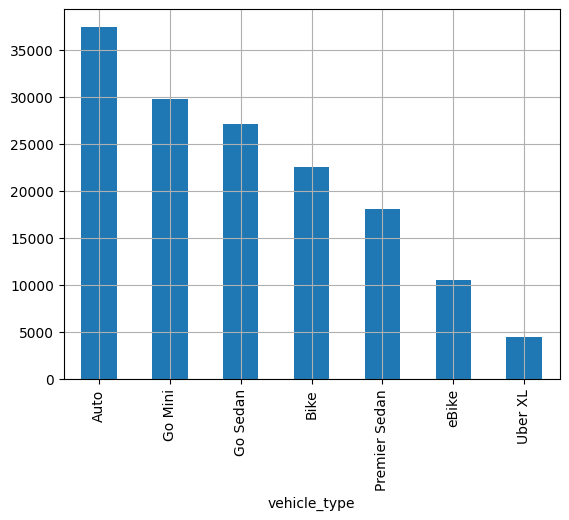

In [30]:
vehicle_counts.plot(kind = "bar", grid = True)

### pickup_location

how is the distribution of the pickup locations? are they all valid?  

In [31]:
# pd.set_option("display.max_rows", None)

pickups = data["pickup_location"].value_counts(dropna = False)
pickups

pickup_location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
                   ... 
Mandi House         800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: count, Length: 176, dtype: int64

I don't have enough domain knowledge to verify whether all pickup locations are properly formatted, but this should be validated at some point

A total of 176 unique pickup locations were identified.
Pickup counts range from 790 to 949.


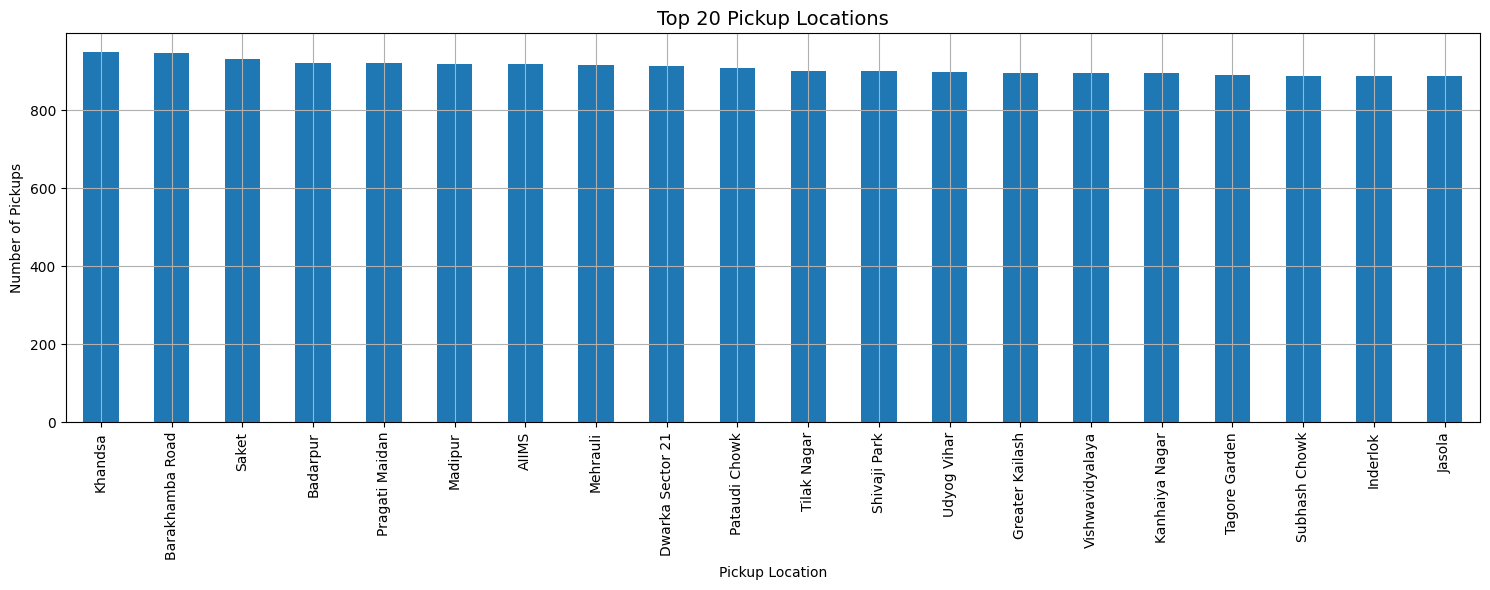

In [ ]:
print(f"A total of {len(pickups)} unique pickup locations were identified.")
print(f"Pickup location counts range from {pickups.min()} to {pickups.max()}.")

ax = pickups.head(20).plot(
    kind="bar",
    figsize=(15,6),
    grid=True
)

ax.set_title("Top 20 Pickup Locations", fontsize=14)
ax.set_xlabel("Pickup Location")
ax.set_ylabel("Number of Pickups")

plt.tight_layout()
plt.show()

### drop location

how is the distribution of the drop locations? are they all valid?  

In [86]:
drops = data["drop_location"].value_counts(dropna = False)
drops

drop_location
Ashram              936
Basai Dhankot       917
Lok Kalyan Marg     916
Narsinghpur         913
Cyber Hub           912
                   ... 
MG Road             799
Bhiwadi             792
Shivaji Park        786
Anand Vihar ISBT    784
Huda City Centre    774
Name: count, Length: 176, dtype: int64

Same situation as pickup locations, it would be worth verifying that all entries are real, properly formatted, and free of errors

A total of 176 unique drop locations were identified.
drops counts range from 774 to 936.


<Axes: title={'center': 'Top 20 Drop Locations'}, xlabel='drop_location'>

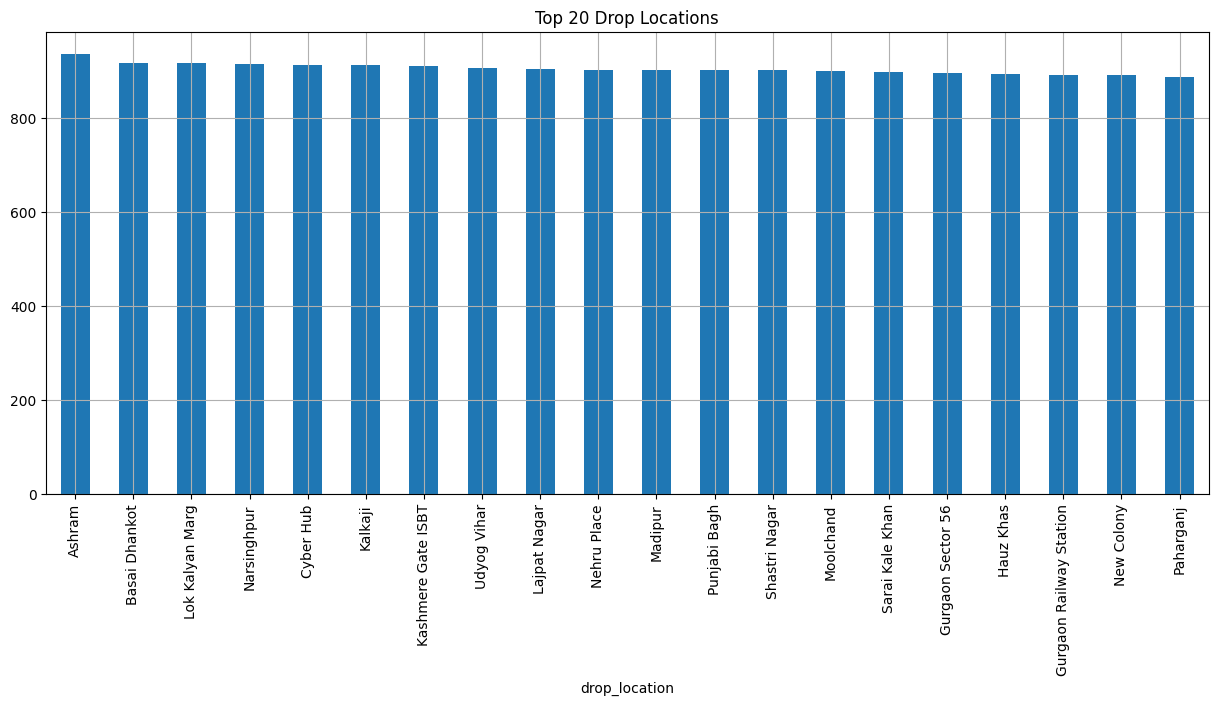

In [87]:
print(f"A total of {len(drops)} unique drop locations were identified.")
print(f"drops counts range from {drops.min()} to {drops.max()}.")

drops.head(20).plot(kind = "bar", figsize=(15,6), grid = True, title = "Top 20 Drop Locations")

### avg_vtat

Average time for driver to reach the pickup location (in minutes)

From stats I can see that there are NaNs, why? how many are they? what is their origin / meaning? 

In [41]:
data["avg_vtat"].unique()

array([10.8,  8.5,  7.4,  5.6,  6.2,  8.1, 11.8,  nan,  7.7, 10.4, 14.3,
        6.7,  2.9,  8.6,  5.5, 10.2,  5.3,  3.1,  3.7,  6.8,  4.8, 14.5,
        3.4,  5.1, 12.1,  5.4, 13.8, 16.8,  4.1,  8.2, 13.1,  7.5,  6.6,
       12.9,  6.5,  6.1,  4.6,  6.3,  9.3, 14.7, 11.5, 13.3,  9.9,  7.8,
       11.4, 13. ,  7.9,  3. ,  8.3,  8.9,  9.7,  8.8,  3.9, 13.7,  3.6,
       12.6, 12.4, 10.3, 11.6,  3.2, 18.3,  2.3,  6.9, 11.3, 11.7,  4.5,
        4.7,  2.2,  2.4,  7.2, 10.6,  7.1,  4.4, 13.6,  6. ,  2.8,  4.3,
        6.4, 19. ,  2.1, 12. ,  2.5,  9.5, 11. , 11.1, 10.5, 12.8,  8.4,
        3.3,  4.2,  4.9, 12.2,  4. ,  2.7,  5.2, 14.1, 16.6,  3.8, 12.7,
       12.5,  9.2, 12.3,  9.1,  2.6, 11.9,  7. ,  5. ,  3.5, 15.2, 14.4,
        5.7, 14.9,  2. , 10.7, 18.2,  9.4, 13.4,  5.8, 19.2,  9. ,  7.6,
       10.1, 15.5, 14.2,  7.3, 19.7,  8.7,  8. , 11.2, 13.9,  5.9, 10. ,
       16.7, 14.8, 10.9,  9.8, 15.6, 19.9, 13.5, 17.6, 15.1, 16.2, 14. ,
       15.4, 14.6, 15. , 18. ,  9.6, 16.9, 19.4, 13

In [42]:
print(f"Total unique values: {data['avg_vtat'].nunique()}")

Total unique values: 181


In [43]:
cancelled_mask = data["is_cancelled"] == 1
avg_vtat_nan_mask = data["avg_vtat"].isna()

exact_match = (cancelled_mask == avg_vtat_nan_mask).all()
print("All cancelled rows match NaNs in ride_distance?", exact_match)

print("Number of cancelled rows:", cancelled_mask.sum())
print("Number of NaN ride_distance rows:", avg_vtat_nan_mask.sum())
print("Number of rows where both are True:", (cancelled_mask & avg_vtat_nan_mask).sum())

All cancelled rows match NaNs in ride_distance? False
Number of cancelled rows: 48000
Number of NaN ride_distance rows: 10500
Number of rows where both are True: 10500


In [44]:
print(f"Total NaNs: {data['avg_vtat'].isna().sum()}")

Total NaNs: 10500


In [45]:
data.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,...,month,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,...,1,False,0.000000,1.000000,10,CNR,4352144,10,CID,8362794
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,...,1,False,0.258819,0.965926,10,CNR,9147645,10,CID,8300238
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,...,1,False,0.258819,0.965926,10,CNR,1009222,10,CID,2030746
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,...,1,False,0.258819,0.965926,10,CNR,2740479,10,CID,3231181
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,...,1,False,0.258819,0.965926,10,CNR,7650148,10,CID,3381661


In [46]:
nan_vtat = data[data["avg_vtat"].isna()]
nan_vtat.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,...,month,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c
7,2024-01-01,02:43:46,CNR4510033,CID3289424,eBike,Udyog Bhawan,Badarpur,NaN,NaN,NaN,...,1,False,0.500000,0.866025,10,CNR,4510033,10,CID,3289424
9,2024-01-01,02:59:14,CNR4588428,CID3087143,Auto,Greater Noida,IMT Manesar,NaN,NaN,NaN,...,1,False,0.500000,0.866025,10,CNR,4588428,10,CID,3087143
44,2024-01-01,07:08:27,CNR4564281,CID1979440,Go Sedan,Janakpuri,Chandni Chowk,NaN,NaN,NaN,...,1,False,0.965926,-0.258819,10,CNR,4564281,10,CID,1979440
56,2024-01-01,07:33:10,CNR7284122,CID7575243,Go Mini,Rajouri Garden,Munirka,NaN,NaN,NaN,...,1,False,0.965926,-0.258819,10,CNR,7284122,10,CID,7575243
58,2024-01-01,07:43:08,CNR5998244,CID7994710,Go Mini,Samaypur Badli,Kanhaiya Nagar,NaN,NaN,NaN,...,1,False,0.965926,-0.258819,10,CNR,5998244,10,CID,7994710


In [47]:
# to confirm in the bivar: 
# relationship between the avg_vtat and the cancellations

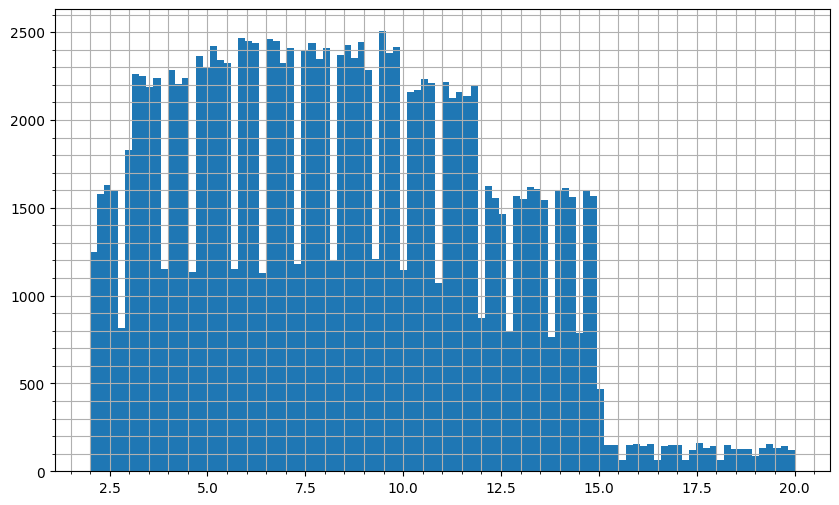

In [48]:
#distribution 
ax = data["avg_vtat"].hist(
    bins=100,
    figsize=(10, 6)
)


ax.minorticks_on()
ax.grid(True, which="both")


Text(0.5, 0, 'minutes')

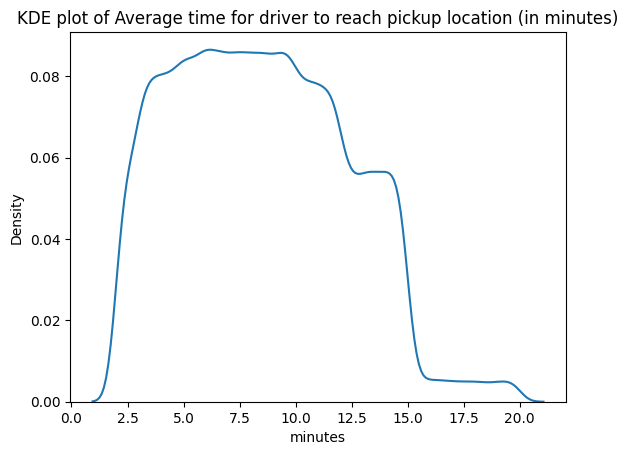

In [49]:
sns.kdeplot(data["avg_vtat"])

plt.title("KDE plot of Average time for driver to reach pickup location (in minutes)")
plt.xlabel("minutes")

The distribution is unimodal and slightly right-skewed with potential outliers. Most observations are concentrated in the range of 2-15 minutes

In [50]:
# are there outliers? how many? 

col = "avg_vtat" 

q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr = q3 - q1

outliers = data[(data[col] < q1 - 1.5 * iqr) | (data[col] > q3 + 1.5 * iqr)]

len(outliers), len(outliers) / len(data)


(0, 0.0)

No outliers

In [51]:
# let's bin it
bins = [0, 5, 10, 15, 20]
labels = ["0-5", "5–10", "10–15", "15–20"]

data["avgvtat_bins"] = pd.cut( data["avg_vtat"], bins=bins,labels=labels)


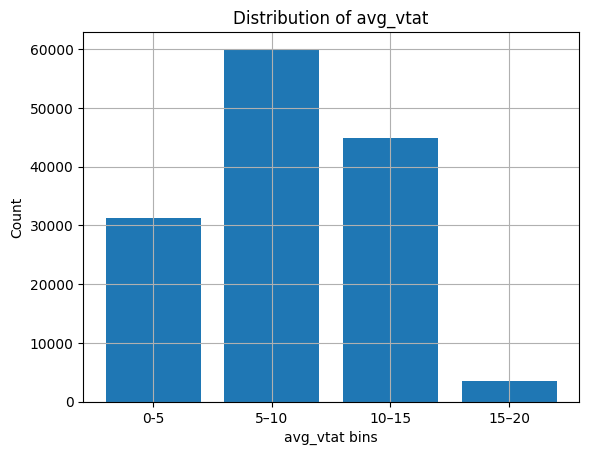

In [52]:
counts = data["avgvtat_bins"].value_counts().sort_index()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("avg_vtat bins")
plt.ylabel("Count")
plt.title("Distribution of avg_vtat")
plt.grid()
plt.show()



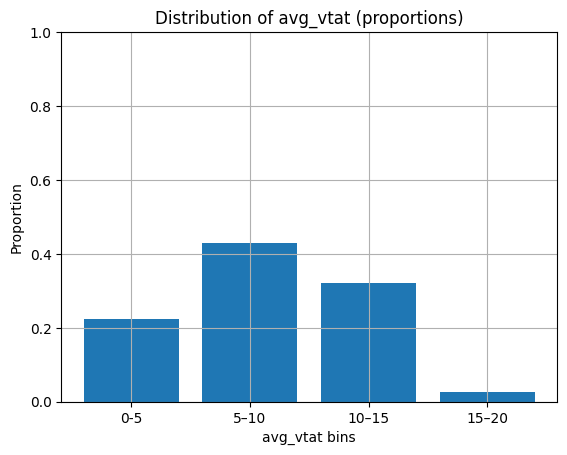

In [53]:
proportions = (
    data["avgvtat_bins"]
    .value_counts(normalize=True)
    .sort_index()
)

plt.figure()
plt.bar(proportions.index.astype(str), proportions.values)
plt.xlabel("avg_vtat bins")
plt.ylabel("Proportion")
plt.title("Distribution of avg_vtat (proportions)")
plt.ylim(0, 1)
plt.grid()
plt.show()

In [54]:
data["avgvtat_bins"].value_counts(normalize=True)

avgvtat_bins
5–10     0.429362
10–15    0.320946
0-5      0.224452
15–20    0.025240
Name: proportion, dtype: float64

Interesting finding. While keeping in mind that I don't have enough context to fully understand the traffic dynamics in this city, it's striking that nearly a third of all rides involve a vehicle arrival time of up to 15 minutes. In my opinion, that could be a contributing factor to cancellations.

I'll analyze both the 5-10 and 10-15 minute bins in the bivariate analysis to look for patterns

### avg_ctat

I'll apply the same set of questions here as I did for avg_vtat

In [55]:
print(f"Total unique values: {data['avg_ctat'].nunique()}")

Total unique values: 351


In [56]:
print(f"Total NaNs: {data['avg_ctat'].isna().sum()}")

Total NaNs: 48000


In this case there are more NaN values — let's look at their characteristics

In [57]:
nan_ctat = data[data["avg_ctat"].isna()]
nan_ctat.head()

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,...,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c,avgvtat_bins
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,...,False,0.258819,0.965926,10,CNR,1009222,10,CID,2030746,5–10
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,...,False,0.258819,0.965926,10,CNR,2740479,10,CID,3231181,5–10
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,...,False,0.258819,0.965926,10,CNR,7650148,10,CID,3381661,5–10
6,2024-01-01,02:14:50,CNR8839592,CID6577042,Bike,Jama Masjid,Sadar Bazar Gurgaon,11.8,NaN,NaN,...,False,0.500000,0.866025,10,CNR,8839592,10,CID,6577042,10–15
7,2024-01-01,02:43:46,CNR4510033,CID3289424,eBike,Udyog Bhawan,Badarpur,NaN,NaN,NaN,...,False,0.500000,0.866025,10,CNR,4510033,10,CID,3289424,NaN


In [58]:
# for the bivar:
# how are the rows that have avg_vtat but no avg_ctat? what does it mean? which characteristics they have? 
# how is the relationship with target? 

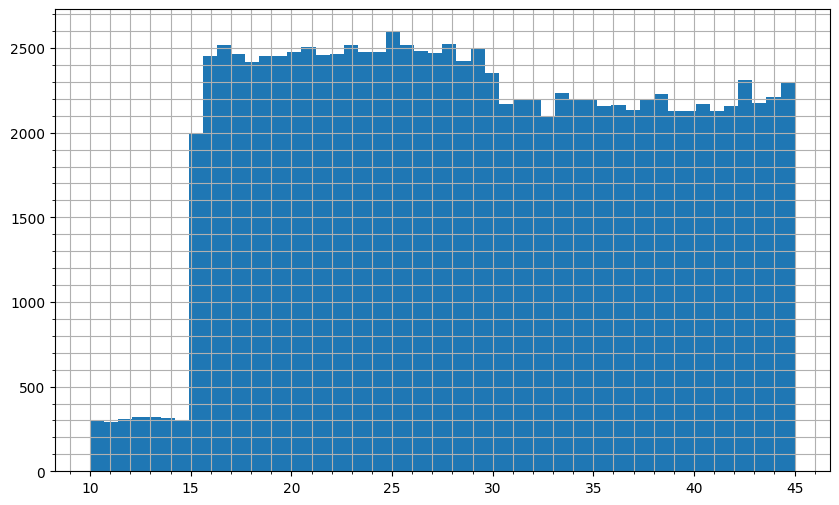

In [59]:
#distribution 
ax = data["avg_ctat"].hist(bins=50, figsize = (10,6))

ax.minorticks_on()
ax.grid(True, which="both")


Text(0.5, 0, 'minutes')

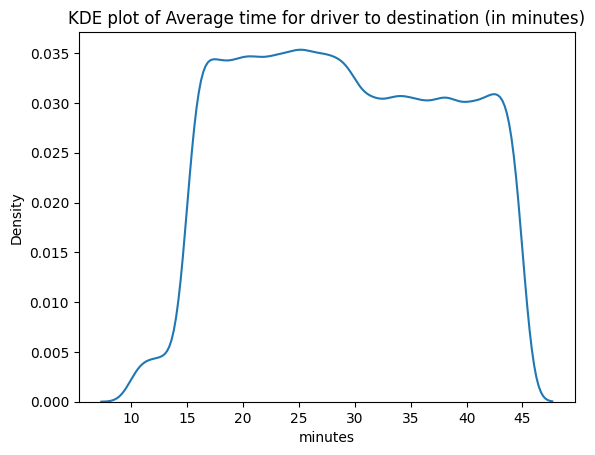

In [60]:
sns.kdeplot(data["avg_ctat"])

plt.title("KDE plot of Average time for driver to destination (in minutes)")
plt.xlabel("minutes")

The distribution is unimodal and slightly right-skewed with potential outliers. Most observations are concentrated in the range of 15-45 minutes

In [61]:
col = "avg_ctat" 

q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr = q3 - q1

outliers = data[(data[col] < q1 - 1.5 * iqr) | (data[col] > q3 + 1.5 * iqr)]

len(outliers), len(outliers) / len(data)


(0, 0.0)

In [62]:
cancelled_mask = data["is_cancelled"] == 1
avg_ctat_nan_mask = data["avg_ctat"].isna()

exact_match = (cancelled_mask == avg_ctat_nan_mask).all()
print("All cancelled rows match NaNs in ride_distance?", exact_match)

print("Number of cancelled rows:", cancelled_mask.sum())
print("Number of NaN ride_distance rows:", avg_ctat_nan_mask.sum())
print("Number of rows where both are True:", (cancelled_mask & avg_ctat_nan_mask).sum())

All cancelled rows match NaNs in ride_distance? True
Number of cancelled rows: 48000
Number of NaN ride_distance rows: 48000
Number of rows where both are True: 48000


Change of plans — this feature cannot be used for modeling

### booking value

Total fare amount for the ride in dollars

In [63]:
# range? NaNs? distribution? the max is above 4k, do I have outliers? unique values? skewness and kurtosis? min-max sanity check?

In [64]:
print(f"Total unique values: {data['booking_value'].nunique()}")

Total unique values: 2566


In [65]:
print(f"Total NaNs: {data['booking_value'].isna().sum()}")

Total NaNs: 48000


In [66]:
data[data["booking_value"].isna()].head()


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,...,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c,avgvtat_bins
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,...,False,0.258819,0.965926,10,CNR,1009222,10,CID,2030746,5–10
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,...,False,0.258819,0.965926,10,CNR,2740479,10,CID,3231181,5–10
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,...,False,0.258819,0.965926,10,CNR,7650148,10,CID,3381661,5–10
6,2024-01-01,02:14:50,CNR8839592,CID6577042,Bike,Jama Masjid,Sadar Bazar Gurgaon,11.8,NaN,NaN,...,False,0.500000,0.866025,10,CNR,8839592,10,CID,6577042,10–15
7,2024-01-01,02:43:46,CNR4510033,CID3289424,eBike,Udyog Bhawan,Badarpur,NaN,NaN,NaN,...,False,0.500000,0.866025,10,CNR,4510033,10,CID,3289424,NaN


The app shows a final price before the rider confirms the booking, at least for cars. It would make sense for bikes and e-bikes to have no booking value, but other vehicle types also have this field missing

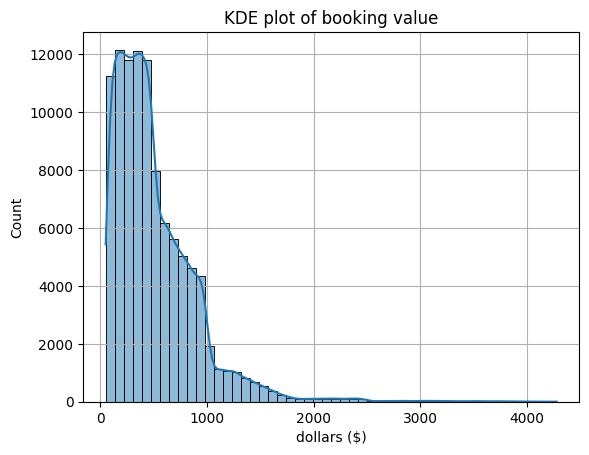

In [67]:
sns.histplot(data["booking_value"], bins=50, kde=True)

plt.title("KDE plot of booking value")
plt.xlabel("dollars ($)")
plt.grid()

The distribution is unimodal, leptokurtic, and more strongly right-skewed than the previous variables. It's important to check for outliers. Most observations are concentrated in the range of 50 to 1,000 dollars

In [68]:
col = "booking_value" 

q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr = q3 - q1

outliers = data[(data[col] < q1 - 1.5 * iqr) | (data[col] > q3 + 1.5 * iqr)]

print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {round(len(outliers) / len(data) * 100, 2)}%")

Number of outliers: 3435
Percentage of outliers: 2.29%


In [69]:
cancelled_mask = data["is_cancelled"] == 1
booking_value_nan_mask = data["booking_value"].isna()

exact_match = (cancelled_mask == booking_value_nan_mask).all()
print("All cancelled rows match NaNs in ride_distance?", exact_match)

print("Number of cancelled rows:", cancelled_mask.sum())
print("Number of NaN ride_distance rows:", booking_value_nan_mask.sum())
print("Number of rows where both are True:", (cancelled_mask & booking_value_nan_mask).sum())
# Ok, change of plans. This feature cannot be used

All cancelled rows match NaNs in ride_distance? True
Number of cancelled rows: 48000
Number of NaN ride_distance rows: 48000
Number of rows where both are True: 48000


### ride_distance

In [70]:
print(f"Total unique values: {data['ride_distance'].nunique()}")

Total unique values: 4901


In [71]:
print(f"Total NaNs: {data['ride_distance'].isna().sum()}")

Total NaNs: 48000


In [72]:
nans_distance = data[data["ride_distance"].isna()].head()
nans_distance

,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,...,is_weekend,hour_sin,hour_cos,booking_length,letters_b,numbers_b,customer_length,letters_c,numbers_c,avgvtat_bins
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,...,False,0.258819,0.965926,10,CNR,1009222,10,CID,2030746,5–10
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,...,False,0.258819,0.965926,10,CNR,2740479,10,CID,3231181,5–10
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,...,False,0.258819,0.965926,10,CNR,7650148,10,CID,3381661,5–10
6,2024-01-01,02:14:50,CNR8839592,CID6577042,Bike,Jama Masjid,Sadar Bazar Gurgaon,11.8,NaN,NaN,...,False,0.500000,0.866025,10,CNR,8839592,10,CID,6577042,10–15
7,2024-01-01,02:43:46,CNR4510033,CID3289424,eBike,Udyog Bhawan,Badarpur,NaN,NaN,NaN,...,False,0.500000,0.866025,10,CNR,4510033,10,CID,3289424,NaN


In [73]:
cancelled_mask = data["is_cancelled"] == 1
ride_distance_nan_mask = data["ride_distance"].isna()

exact_match = (cancelled_mask == ride_distance_nan_mask).all()
print("All cancelled rows match NaNs in ride_distance?", exact_match)

print("Number of cancelled rows:", cancelled_mask.sum())
print("Number of NaN ride_distance rows:", ride_distance_nan_mask.sum())
print("Number of rows where both are True:", (cancelled_mask & ride_distance_nan_mask).sum())

# it cannot be used

All cancelled rows match NaNs in ride_distance? True
Number of cancelled rows: 48000
Number of NaN ride_distance rows: 48000
Number of rows where both are True: 48000


In [74]:
len(data[data["is_cancelled"] == 1.0])

48000

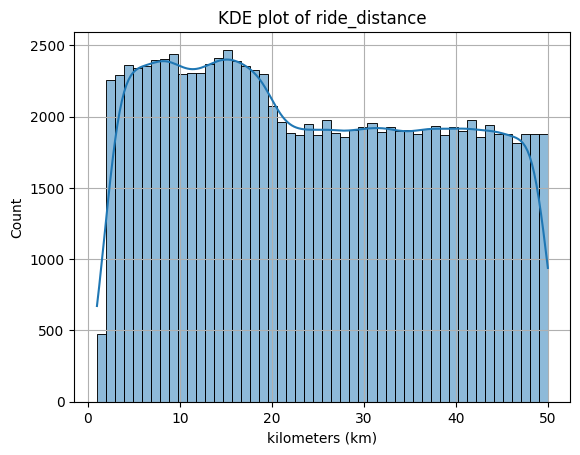

In [75]:
sns.histplot(data["ride_distance"], bins=50, kde=True)

plt.title("KDE plot of ride_distance")
plt.xlabel("kilometers (km)")
plt.grid()

The distribution is unimodal, platykurtic, and moderately right-skewed, so outliers are unlikely. Most observations fall between 3 and 20 km

In [76]:
col = "ride_distance" 

q1 = data[col].quantile(0.25)
q3 = data[col].quantile(0.75)
iqr = q3 - q1

outliers = data[(data[col] < q1 - 1.5 * iqr) | (data[col] > q3 + 1.5 * iqr)]

print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of outliers: {round(len(outliers) / len(data) * 100, 2)}%")

Number of outliers: 0
Percentage of outliers: 0.0%


As expected

### payment method

Method used for payment (UPI, Cash, Credit Card, Uber Wallet, Debit Card)

In [77]:
payment_counts = data["payment_method"].value_counts(dropna = False)
payment_counts

payment_method
NaN            48000
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

In [78]:
payment_counts.index.to_list()

[nan, 'UPI', 'Cash', 'Uber Wallet', 'Credit Card', 'Debit Card']

<Axes: xlabel='payment_method'>

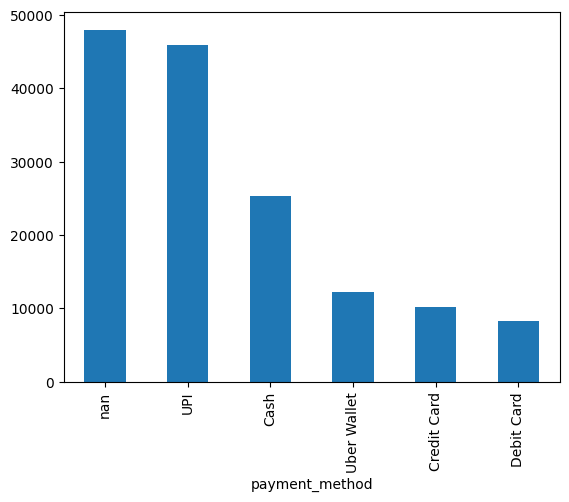

In [79]:
payment_counts.plot(kind = "bar")

The Unified Payments Interface (UPI) is India's real-time payment system for instant bank-to-bank transfers via smartphones.

The debit card category is quite small on its own — it might make sense to merge it with credit card for modeling purposes

In [80]:
cancelled_mask = data["is_cancelled"] == 1
payment_method_nan_mask = data["payment_method"].isna()

exact_match = (cancelled_mask == payment_method_nan_mask).all()
print("All cancelled rows match NaNs in ride_distance?", exact_match)

print("Number of cancelled rows:", cancelled_mask.sum())
print("Number of NaN ride_distance rows:", payment_method_nan_mask.sum())
print("Number of rows where both are True:", (cancelled_mask & payment_method_nan_mask).sum())

# it cannot be used

All cancelled rows match NaNs in ride_distance? True
Number of cancelled rows: 48000
Number of NaN ride_distance rows: 48000
Number of rows where both are True: 48000


## is_cancelled 

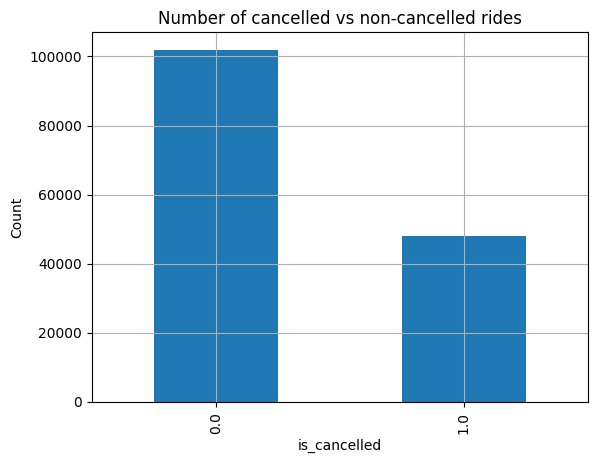

In [81]:
data["is_cancelled"].value_counts().plot(kind="bar")
plt.xlabel("is_cancelled")
plt.ylabel("Count")
plt.title("Number of cancelled vs non-cancelled rides")
plt.grid()
plt.show()


In [82]:
data["is_cancelled"].value_counts(normalize=True)

is_cancelled
0.0    0.68
1.0    0.32
Name: proportion, dtype: float64